<a href="https://colab.research.google.com/github/dr-bankert-augustana/PHYS_200/blob/main/Lesson_3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a name="Notebook-Start"></a>

---

<font size = 7> <b> Lesson 3.2 (Bike-Share Continued) </b> </font>

---

<font size = 5> <b> Notebook Index </b> </font>

1.  [Learning Outcomes](#Learning-Outcomes)

2.  [Introduction](#Introduction)

3.  [Implementing the State](#State)

4.  [Changing the State](#Change)

5.  [Stepping Forward In Time](#Time)
$
\newcommand{\lsum}{\displaystyle \sum\limits_{i=1}^{N}}
\newcommand{\parens}[1]{\left(#1\right)}
\newcommand{\dsfrac}[2]{\displaystyle\frac{#1}{#2}}
\newcommand{\dpfrac}[2]{\displaystyle\parens{\frac{#1}{#2}}}
\newcommand{\parderiv}[2]{\dsfrac{\partial #1}{\partial #2}}
\newcommand{\spc}{\hspace{0.1 pc}}
\newcommand{\ra}{\Rightarrow}
\newcommand{\of}[1]{{\scriptsize (#1)}}
\newcommand{\rule}{\Huge \hspace{-0.2 pc} \displaystyle\frac{\hspace{20 pc}}{\hspace{20 pc}}}
\newcommand{\mps}{\spc \frac{\textrm{m}}{\textrm{s}}}
\newcommand{\mpss}{\spc \frac{\textrm{m}}{\textrm{s}^2}}
$

<a name="Learning-Outcomes"></a>

---

<font size = 6> <b> 1. Learning Outcomes </b> </font>

---

<font size = 5> <b> Learning Outcomes: </b> </font>

By the end of this lesson, students will be able to:

  <br>

  1.

[Return to Top](#Notebook-Start)

<a name="Introduction"></a>

---

<font size = 6> <b> 2. Introduction </b> </font>

---

<font size = 5> <b> 2.1 Recapping the Bike-share Problem </b> </font>

<p align = 'justify'>
We are interested in instituting a bike share system for students traveling between Augie and downtown Moline. By observation, we know that more students use the bikes to get from Augie to Moline than the reverse, so bikes tend to build up at Moline. We only want to move bikes once every day from Moline to Augie. We know we have 12 bikes in total.
</p>

<br>

<p align = 'justify'>
 <b>If we want as few disappointed customers as possible, how many bikes should we put in each place at the start of the day?</b>
</p>

<center>$\rule$</center>

<font size = 5> <b> 2.2 What We Have So Far </b> </font>

Time Step,augie,moline
0,10,2
1,10,2
2,9,3
3,8,4
4,8,4
...,...,...
56,15,-3
57,16,-4
58,15,-3
59,15,-3



Final System State:

Number of Bikes at Augie: 14
Number of Bikes at Moline: -2



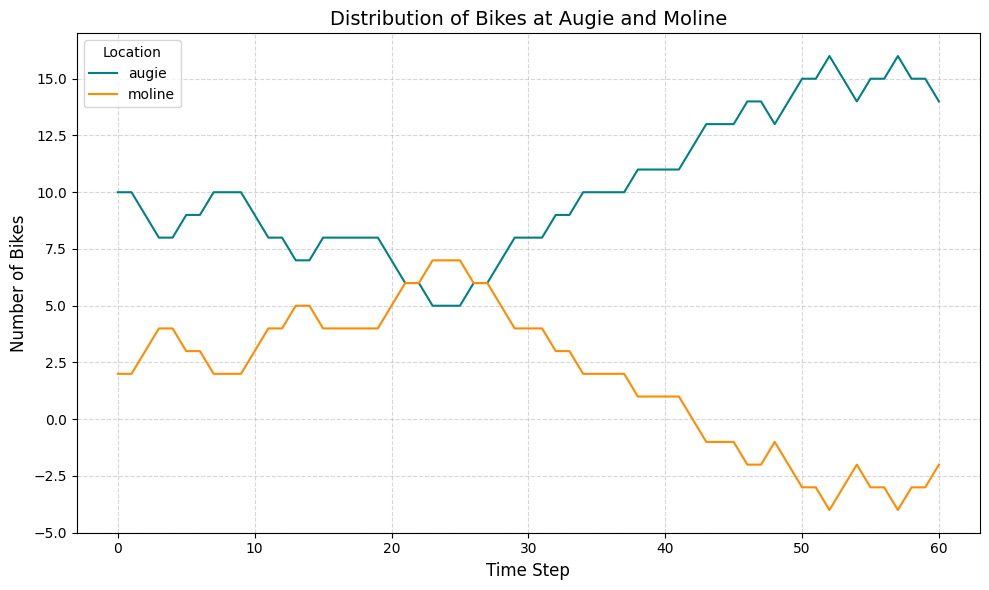

In [4]:
##=============================================================================================##
## Import Libraries                                                                            ##
##=============================================================================================##

import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt

##=============================================================================================##
## Define the Change Function:                                                                 ##
##=============================================================================================##

# Define bike_to_moline:

def bike_to_moline(state):

    # Remove a bike from Augie:

    state.augie -= 1

    # Add a bike to Moline:

    state.moline += 1

    # Return the altered system_state:

    return state

# Define bike_to_augie:

def bike_to_augie(state):

    # Remove a bike from Moline:

    state.moline -= 1

    # Add a bike to Augie:

    state.augie += 1

    # Return the altered system_state:

    return state

# Define change_function:

def change_function(state, prob_to_moline, prob_to_augie, debug = False):

  # Define the 'to_moline' random number:

  random_to_moline = npr.random()

  # Define the 'to_augie' random number:

  random_to_augie = npr.random()

  # Check to see if 'random_to_moline' is less than the threshold for calling 'bike_to_moline':

  if (random_to_moline < prob_to_moline): state = bike_to_moline(state)

  # Check to see if 'random_to_moline' is less than the threshold for calling 'bike_to_augie':

  if (random_to_augie < prob_to_augie): state = bike_to_augie(state)

  # Check the internal values if debug is True:

  if (debug == True):

    print("Threshold to Moline: " + str(prob_to_moline))
    print("Random to Moline: " + str(random_to_moline))

    if (random_to_moline < prob_to_moline): print("Bike Moved to Moline")
    else: print("Bike Not Moved to Moline")

    print()
    print("Threshold to Augie: " + str(prob_to_augie))
    print("Random to Augie: " + str(random_to_augie))

    if (random_to_augie < prob_to_augie): print("Bike Moved to Augie")
    else: print("Bike Not Moved to Augie")

    print()

  # Return the updated system state:

  return state

##=============================================================================================##
## Set the Simulation Parameters:                                                              ##
##=============================================================================================##

# Set the total number of bikes:

n_bikes = 12

# Set the number of bikes to start at Augustana:

n_augie = 10

# Set the probability of a bike moving from Augustana to Moline:

p_to_moline = 0.5

# Set the probability of a bike moving from Moline to Augustana:

p_to_augie = 0.4

# Set the number of time steps:

n_steps = 60

##=============================================================================================##
## Create the System's Initial State and State History:                                        ##
##=============================================================================================##

# Create a Pandas Series to store the system's state:

system_state = pd.Series({"augie" : n_augie, "moline" : n_bikes - n_augie})

# Create the state_history DataFrame:

state_history = pd.DataFrame()

state_history.name = 'Bikes at Augie'

state_history.index.name = 'Time Step'

# Set the first entry in the state_history to be the initial system state:

state_history[0] = system_state

state_history = state_history.T

##=============================================================================================##
## Run the Simulation for the Desired Number of Time Steps:                                    ##
##=============================================================================================##

for i in range(n_steps):

  # Get the state of the system for the current time step:

  system_state = change_function(system_state, p_to_moline, p_to_augie)

  # Store the new system state in the state_history DataFrame:

  state_history.loc[i + 1] = system_state.T

##=============================================================================================##
## Examine the Results of the Simulation:                                                      ##
##=============================================================================================##

# View the system's state history:

display(state_history)

# Print out the final system state:

print()
print("Final System State:")
print()
print("Number of Bikes at Augie: " + str(state_history.iloc[-1, 0]))
print("Number of Bikes at Moline: " + str(state_history.iloc[-1, 1]))
print()

##=============================================================================================##
## Create a Graph of the System's State History:                                               ##
##=============================================================================================##

# Create the plot of the DataFrame:

ax = state_history.plot(
    kind = 'line',
    y = ['augie', 'moline'],
    color = ['teal', 'darkorange'],
    figsize = (10, 6)
)

# Add titles and labels to the plot:

ax.set_title("Distribution of Bikes at Augie and Moline", fontsize = 14)

ax.set_xlabel("Time Step", fontsize = 12)

ax.set_ylabel("Number of Bikes", fontsize = 12)

# Add grid and legend:

plt.grid(True, linestyle = '--', alpha=0.5)
plt.legend(title = "Location")

plt.tight_layout()

# Display the plot:

plt.show()

<a name="Iteration"></a>

---

<font size = 6> <b> 3. Improving the Code through Iteration </b> </font>

---

<font size = 5> <b> 3.1 Identifying Model Weaknesses </b> </font>

The model we have so far is simple, but it is based on unrealistic
assumptions. What weaknesses can we identify in our model?

<br>

-   In the model, a student is equally likely to arrive during any
    15-minute period. In reality, this probability varies depending on time of day, day of the week, etc.

-   The model does not account for travel time from one bike station to another.

-   The model does not allow more than one student to arrive in a given 15-minute period.

-   The model does not check whether a bike is available, so it's
    possible for the number of bikes to be negative (as you might have
    noticed in some of your simulations).

<br>

Some of these modeling decisions are better than others:

* the first assumption might be reasonable if we simulate the system for a short period of time, like one hour.
* the second and third assumptions are not very realistic, but they might not affect the results very much, depending on what we use the model for.

The last assumption seems problematic, and not to hard to fix.  So let's start there.

<br>

><b>Note:</b> This is how incremental development works: start with a simple model, identifying the most important problems, and make improvements one step at a time. It often takes several iterations to develop a model that is good enough for the intended purpose, but no more complicated than necessary.

<center>$\rule$</center>

<font size = 5> <b> 3.2 Development 1: Eliminating Negative Bikes </b> </font>

Currently the simulation does not check whether a bike is available when a customer arrives, so the number of bikes at a location can be
negative. That's not very realistic. Here is a new version of the `change_function` that fixes the problem:

In [47]:
##=============================================================================================##
## Define the Change Function:                                                                 ##
##=============================================================================================##

def change_function(state, prob_to_moline, prob_to_augie, debug = False):

  # Define the 'to_moline' random number:

  random_to_moline = npr.random()

  # Define the 'to_augie' random number:

  random_to_augie = npr.random()

  # Check to see if 'random_to_moline' is less than the threshold for calling 'bike_to_moline':

  if ((random_to_moline < prob_to_moline) and (state.augie > 0)): state = bike_to_moline(state)

  # Check to see if 'random_to_moline' is less than the threshold for calling 'bike_to_augie':

  if ((random_to_augie < prob_to_augie) and (state.moline > 0)): state = bike_to_augie(state)

  # Check the internal values if debug is True:

  if (debug == True):

    print("Threshold to Moline: " + str(prob_to_moline))
    print("Random to Moline: " + str(random_to_moline))

    if (random_to_moline < prob_to_moline): print("Bike Moved to Moline")
    else: print("Bike Not Moved to Moline")

    print()
    print("Threshold to Augie: " + str(prob_to_augie))
    print("Random to Augie: " + str(random_to_augie))

    if (random_to_augie < prob_to_augie): print("Bike Moved to Augie")
    else: print("Bike Not Moved to Augie")

    print()

  # Return the updated system state:

  return state


The first line in each function checks whether the number of bikes available at a particular location is greater than zero. If not, it skips to the return line of the function and the state is unchanged.

<br>

We can test our new functions by initializing a state with no bikes at Moline and calling `change_function`.

In [50]:
##=============================================================================================##
## Test the New Change Function:                                                               ##
##=============================================================================================##

# Create a System State With No Bikes at the Moline Bike Rack:

state = pd.Series({"augie" : n_bikes, "moline" : 0}, name = "Number of Bikes")

# Print the number of bikes at each location in the initial system state:

print("Number of Bikes at Augie: " + str(state.augie))
print("Number of Bikes at Moline: " + str(state.moline))
print()

# Call the bike_to_augie function:

state = change_function(state, 0.5, 0.4)

# Print the number of bikes at each location in the updated system state:

print("Number of Bikes at Augie: " + str(state.augie))
print("Number of Bikes at Moline: " + str(state.moline))
print()

Number of Bikes at Augie: 12
Number of Bikes at Moline: 0

Number of Bikes at Augie: 12
Number of Bikes at Moline: 0



<center>$\rule$</center>

<font size = 5> <b> 3.3 Development 2: Running the Simulation as a Single Function </b> </font>

Some incremental development, like eliminating negative bikes, concern the accuracy of the simulation. Others, though, are designed to help the simulation run more smoothly.  Let's try one of those here.

<br>

We want to put it all the moving parts of our simulation under the umbrella of a single function called `run_simulation()`.

In [52]:
##=============================================================================================##
## Create a Function to Set Up and Run the Simulation:                                         ##
##=============================================================================================##

def run_simulation(parameters):

  ##===========================================================================================##
  ## Unpack the Simulation Parameters:                                                         ##
  ##===========================================================================================##

  # Set the total number of bikes:

  n_bikes = parameters.n_bikes

  # Set the number of bikes to start at the Augustana bike rack:

  n_augie = parameters.n_augie

  # Set the probability of a bike travelling to Moline in a given time step:

  p_to_moline = parameters.p_to_moline

  # Set the probability of a bike travelling to Augustana in a given time step:

  p_to_augie = parameters.p_to_augie

  # Set the total number of time steps:

  n_steps = int(parameters.n_steps)

  ##===========================================================================================##
  ## Create the System's Initial State and State History:                                      ##
  ##===========================================================================================##

  # Create a Pandas Series to store the system's state:

  system_state = pd.Series({"augie" : n_augie, "moline" : n_bikes - n_augie})

  # Create the state_history DataFrame:

  state_history = pd.DataFrame()

  state_history.name = 'Bikes at Augie'

  state_history.index.name = 'Time Step'

  # Set the first entry in the state_history to be the initial system state:

  state_history[0] = system_state

  state_history = state_history.T

  ##===========================================================================================##
  ## Run the Simulation for the Desired Number of Time Steps:                                  ##
  ##===========================================================================================##

  for i in range(n_steps):

    # Get the state of the system for the current time step:

    system_state = change_function(system_state, p_to_moline, p_to_augie)

    # Store the new system state in the state_history DataFrame:

    state_history.loc[i + 1] = system_state.T

  ##===========================================================================================##
  ## Return the System's State History:                                                        ##
  ##===========================================================================================##

  return state_history

We can call `run_simulation` like this:

Time Step,augie,moline
0,10.0,2.0
1,10.0,2.0
2,11.0,1.0
3,11.0,1.0
4,10.0,2.0
...,...,...
56,0.0,12.0
57,1.0,11.0
58,1.0,11.0
59,1.0,11.0



Final System State:

Number of Bikes at Augie: 0.0
Number of Bikes at Moline: 12.0



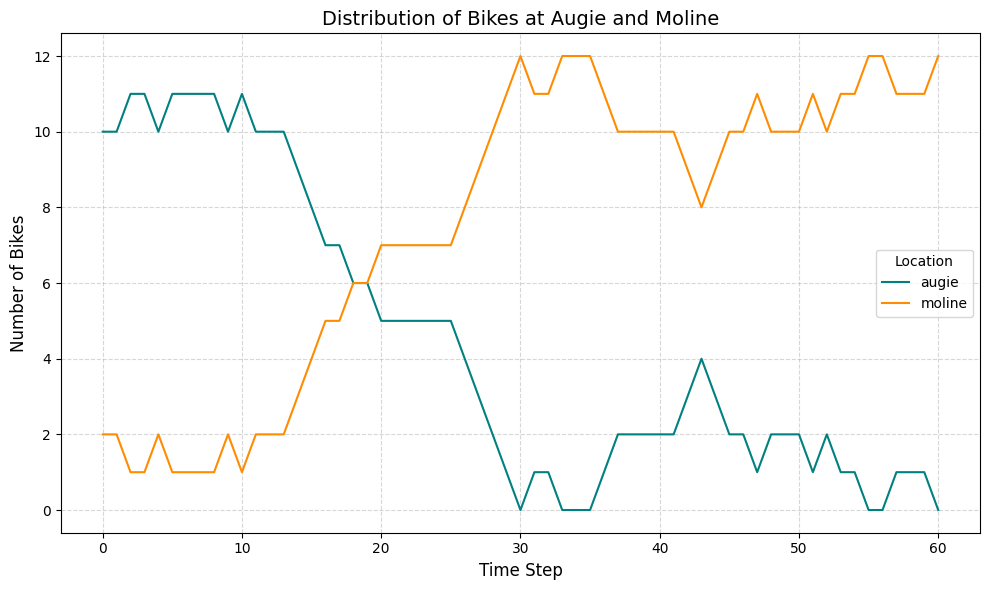

In [59]:
##=============================================================================================##
## Define the Simulation's Parameters:                                                         ##
##=============================================================================================##

parameters = pd.Series({
    "n_bikes" : 12,
    "n_augie" : 10,
    "p_to_moline" : 0.5,
    "p_to_augie" : 0.4,
    "n_steps" : 60
})

##=============================================================================================##
## Run the Simulation:                                                                         ##
##=============================================================================================##

simulation_history = run_simulation(parameters)

##=============================================================================================##
## Display the Simulation's Results:                                                           ##
##=============================================================================================##

# View the system's state history:

display(simulation_history)

# Print out the final system state:

print()
print("Final System State:")
print()
print("Number of Bikes at Augie: " + str(simulation_history.iloc[-1, 0]))
print("Number of Bikes at Moline: " + str(simulation_history.iloc[-1, 1]))
print()

##=============================================================================================##
## Create a Graph of the System's State History:                                               ##
##=============================================================================================##

# Create the plot of the DataFrame:

ax = simulation_history.plot(
    kind = 'line',
    y = ['augie', 'moline'],
    color = ['teal', 'darkorange'],
    figsize = (10, 6)
)

# Add titles and labels to the plot:

ax.set_title("Distribution of Bikes at Augie and Moline", fontsize = 14)

ax.set_xlabel("Time Step", fontsize = 12)

ax.set_ylabel("Number of Bikes", fontsize = 12)

# Add grid and legend:

plt.grid(True, linestyle = '--', alpha=0.5)
plt.legend(title = "Location")

plt.tight_layout()

# Display the plot:

plt.show()